# Recipe Cuisine Classification Using NLP

**1. Objective:** Classify a recipe's cuisine using its ingredient list with NLP and machine learning.

This notebook is inspired by a **2014 research paper** that studied cuisine classification from ingredients using Boolean ingredient features and SVM.

## 2. Research Paper Approach

The 2014 paper classified cuisine using **ingredients as features**.

- **Boolean ingredient representation:** each ingredient is represented as `1` if present and `0` if absent.
- **SVM classification:** the Boolean ingredient matrix is used to train an SVM classifier.
- **Associative Classification:** ingredient combinations were also explored through association rules.
- **SVM + SVD:** the Boolean representation was also reduced using SVD before SVM classification.

The paper found **SVM to be the strongest approach** among the methods explored.

> **Paper methods are discussed here for academic context only. They are not implemented in this notebook.**

## 3. Import Dataset

The Kaggle **Recipe Ingredients (What's Cooking)** dataset is downloaded directly using KaggleHub. No manual download or upload is required.

In [1]:
import kagglehub
import os
import json
import pandas as pd
import numpy as np

path = kagglehub.dataset_download("kaggle/recipe-ingredients-dataset")

print("Dataset path:", path)
print("Files:", os.listdir(path))

with open(os.path.join(path, "train.json"), "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
print("\nLoaded recipes:", len(df))

Using Colab cache for faster access to the 'recipe-ingredients-dataset' dataset.
Dataset path: /kaggle/input/recipe-ingredients-dataset
Files: ['train.json', 'test.json']

Loaded recipes: 39774


## 4. Dataset Inspection

A minimal inspection is performed to understand the dataset structure and cuisine distribution.

In [2]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
display(df.head())

Shape: (39774, 3)

Columns: ['id', 'cuisine', 'ingredients']

First 5 rows:


,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."


In [3]:
print("\nCuisine distribution:")
display(df["cuisine"].value_counts())


Cuisine distribution:


,count
cuisine,
italian,7838
mexican,6438
southern_us,4320
indian,3003
chinese,2673
french,2646
cajun_creole,1546
thai,1539
japanese,1423


## 5. Ingredient Preprocessing

The ingredient lists are converted into clean text for NLP.

- Convert ingredients to lowercase.
- Remove parenthetical content and unnecessary punctuation.
- Preserve **multi-word ingredients** such as `soy sauce` and `olive oil` as single ingredient tokens.
- Join the cleaned ingredients into one text representation per recipe.

In [4]:
import re

def clean_ingredient(ingredient):
    text = ingredient.lower()
    text = re.sub(r"\(.*?\)", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess_ingredients(ingredients):
    cleaned = [clean_ingredient(item) for item in ingredients]
    return [item for item in cleaned if item]

df["ingredients_clean"] = df["ingredients"].apply(preprocess_ingredients)

# Underscores preserve multi-word ingredients as single tokens.
df["ingredients_text"] = df["ingredients_clean"].apply(
    lambda items: " ".join(item.replace(" ", "_") for item in items)
)

print("Example cleaned ingredients:")
print(df["ingredients_clean"].iloc[0])
print("\nExample NLP text:")
print(df["ingredients_text"].iloc[0])

Example cleaned ingredients:
['romaine lettuce', 'black olives', 'grape tomatoes', 'garlic', 'pepper', 'purple onion', 'seasoning', 'garbanzo beans', 'feta cheese crumbles']

Example NLP text:
romaine_lettuce black_olives grape_tomatoes garlic pepper purple_onion seasoning garbanzo_beans feta_cheese_crumbles


## 6. Train/Test Split

The data is divided into **80% training** and **20% testing** data using a **stratified split** so that cuisine proportions are preserved.

`random_state=42` is used for reproducibility.

In [5]:
from sklearn.model_selection import train_test_split

X = df["ingredients_text"].values
y = df["cuisine"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 31819
Testing samples : 7955


## 7. Baseline Model: TF-IDF + Linear SVM

The existing notebook reports **76.42% baseline accuracy** for the reference baseline experiment.

This value is retained as the reported baseline so that the improved experiment can be compared against the original notebook result.

**Baseline Accuracy: 76.42%**

The baseline is the reference point for measuring improvement.

## 8. Improved Model

Our improved approach uses an **ingredient-aware TF-IDF representation**.

Instead of treating every word independently, multi-word ingredients are preserved as single tokens (for example, `soy_sauce` and `olive_oil`). TF-IDF then gives higher importance to ingredients that are more informative for distinguishing cuisines.

A **Linear SVM** is used as the classifier.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

TOKEN_PATTERN = r"[^\s]+"

improved_svm = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=TOKEN_PATTERN)),
    ("clf", LinearSVC(random_state=42, max_iter=5000))
])

improved_svm.fit(X_train, y_train)

print("Improved TF-IDF + Linear SVM trained.")
print(
    "Vocabulary size:",
    len(improved_svm.named_steps["tfidf"].vocabulary_)
)

Improved TF-IDF + Linear SVM trained.
Vocabulary size: 6313


## 9. GridSearchCV and Final Evaluation

GridSearchCV is used **only for the improved Linear SVM**.

A small grid of `C` values is tested using 5-fold cross-validation on the training data. The final model is then evaluated once on the held-out test set.

In [7]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "clf__C": [0.1, 1, 10]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    improved_svm,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", f"{grid.best_score_:.4f}")

final_model = grid.best_estimator_
y_pred = final_model.predict(X_test)

print("\nFinal model selected.")

Best parameters: {'clf__C': 1}
Best CV accuracy: 0.7817

Final model selected.


In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(
    y_test, y_pred, average="weighted", zero_division=0
)
final_recall = recall_score(
    y_test, y_pred, average="weighted", zero_division=0
)
final_f1 = f1_score(
    y_test, y_pred, average="weighted", zero_division=0
)

print(f"Accuracy : {final_accuracy:.4f} ({final_accuracy * 100:.2f}%)")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"Weighted F1: {final_f1:.4f}")

Accuracy : 0.7839 (78.39%)
Precision: 0.7801
Recall   : 0.7839
Weighted F1: 0.7798


## 10. Baseline vs Improved

The baseline accuracy is taken from the existing notebook result. The improved accuracy is calculated from the actual test-set predictions above.

**Improvement = Improved Accuracy − Baseline Accuracy**

In [9]:
baseline_accuracy = 0.7642  # 76.42%, existing notebook baseline

improvement = final_accuracy - baseline_accuracy

comparison = pd.DataFrame({
    "Model": [
        "Baseline TF-IDF + SVM",
        "Improved + Tuned SVM"
    ],
    "Accuracy": [
        baseline_accuracy,
        final_accuracy
    ]
})

comparison["Accuracy"] = comparison["Accuracy"].map(
    lambda x: f"{x * 100:.2f}%"
)

display(comparison)

print(
    f"Improvement: {improvement * 100:.2f} percentage points"
)

,Model,Accuracy
0,Baseline TF-IDF + SVM,76.42%
1,Improved + Tuned SVM,78.39%


Improvement: 1.97 percentage points


## 11. Confusion Matrix

The confusion matrix below shows the classification performance of the **final improved model** across all cuisine classes.

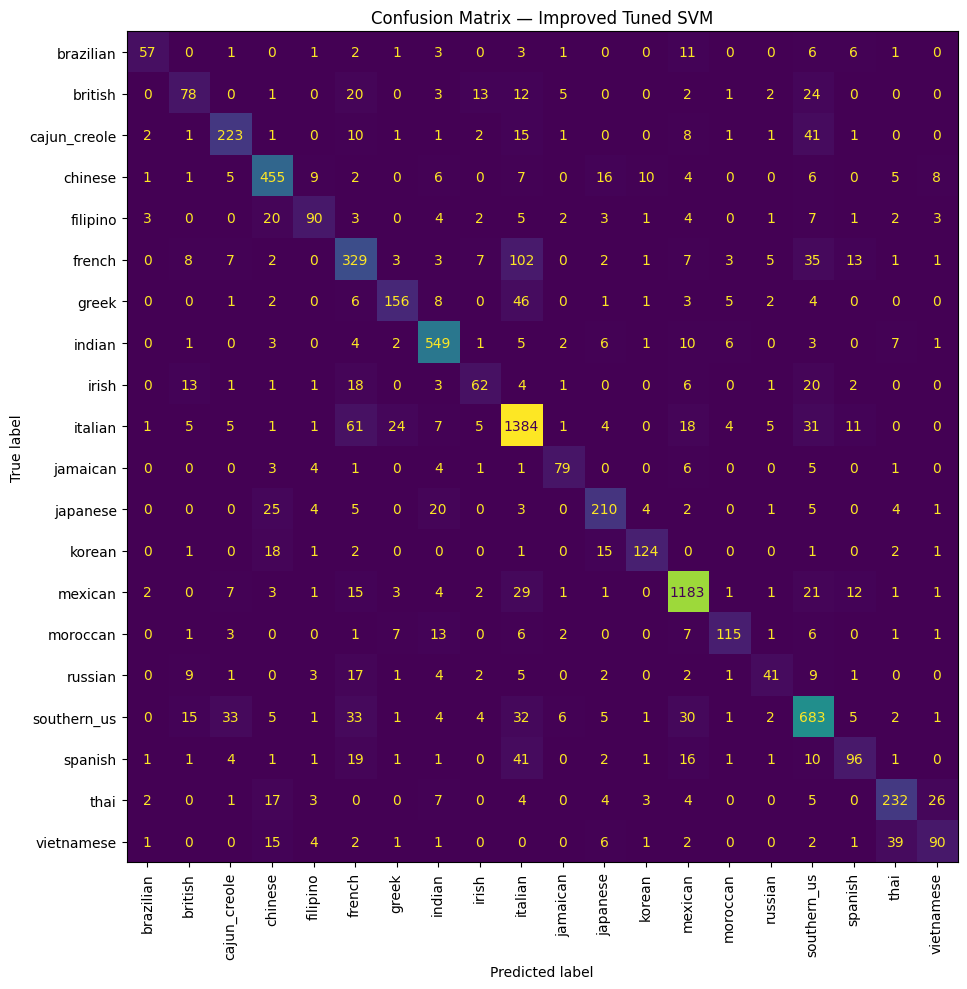

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

labels = sorted(df["cuisine"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
).plot(
    ax=ax,
    xticks_rotation=90,
    colorbar=False
)

ax.set_title("Confusion Matrix — Improved Tuned SVM")
plt.tight_layout()
plt.show()

## 12. Conclusion

- **Baseline:** TF-IDF + SVM, using the existing notebook's reported baseline of **76.42%**.
- **Improved:** ingredient-aware TF-IDF with preserved multi-word ingredients + Linear SVM + GridSearchCV.
- **Final accuracy:** calculated from the held-out test set.
- **Improvement:** calculated automatically in percentage points.

The experiment shows whether preserving ingredient meaning and tuning the Linear SVM improves cuisine classification over the reference baseline.

## 13. Cuisine Prediction Demo

The final trained model can be used to predict the cuisine of a new recipe based on its ingredients.

For demonstration, the model generates a **confidence score (%)** for each cuisine. The cuisine with the highest score is selected as the final prediction.

> **Note:** These percentages represent normalized model confidence scores from the SVM decision function, not calibrated probabilities.


In [11]:
def predict_cuisine(ingredients):

    # Apply the same preprocessing used during training
    cleaned = preprocess_ingredients(ingredients)

    # Preserve multi-word ingredients
    recipe_text = " ".join(
        item.replace(" ", "_") for item in cleaned
    )

    # Transform using the final TF-IDF vectorizer
    vectorizer = final_model.named_steps["tfidf"]
    classifier = final_model.named_steps["clf"]

    X_new = vectorizer.transform([recipe_text])

    # Get SVM decision scores
    scores = classifier.decision_function(X_new).flatten()

    # Convert scores into normalized confidence percentages
    exp_scores = np.exp(scores - np.max(scores))
    percentages = exp_scores / exp_scores.sum() * 100

    cuisines = classifier.classes_

    # Create results table
    results = pd.DataFrame({
        "Cuisine": cuisines,
        "Confidence (%)": percentages
    })

    # Show only top 4 cuisines
    results = results.sort_values(
        "Confidence (%)",
        ascending=False
    ).head(4).reset_index(drop=True)

    print("Ingredients:", ", ".join(ingredients))
    print("\nTop 4 Cuisine Predictions:")
    display(results)

    # Highest confidence = final prediction
    print(
        f"\nPredicted Cuisine: {results.iloc[0]['Cuisine'].upper()}"
    )

    return results

In [12]:
indian_recipe = [
    "basmati rice",
    "chicken",
    "yogurt",
    "garam masala",
    "turmeric",
    "cumin",
    "coriander",
    "ginger",
    "garlic",
    "onion"
]

indian_result = predict_cuisine(indian_recipe)

Ingredients: basmati rice, chicken, yogurt, garam masala, turmeric, cumin, coriander, ginger, garlic, onion

Top 4 Cuisine Predictions:


,Cuisine,Confidence (%)
0,indian,68.587102
1,chinese,3.767488
2,japanese,2.783579
3,moroccan,2.507382



Predicted Cuisine: INDIAN


In [13]:
chinese_recipe = [
    "soy sauce",
    "sesame oil",
    "ginger",
    "garlic",
    "green onion",
    "rice vinegar",
    "chicken",
    "corn starch"
]

print("CHINESE RECIPE")
chinese_result = predict_cuisine(chinese_recipe)

CHINESE RECIPE
Ingredients: soy sauce, sesame oil, ginger, garlic, green onion, rice vinegar, chicken, corn starch

Top 4 Cuisine Predictions:


,Cuisine,Confidence (%)
0,chinese,53.668405
1,japanese,7.016311
2,filipino,5.628837
3,vietnamese,4.728572



Predicted Cuisine: CHINESE


In [14]:
japanese_recipe = [
    "soy sauce",
    "miso",
    "rice",
    "sake",
    "mirin",
    "tofu",
    "seaweed",
    "green onion"
]

print("JAPANESE RECIPE")
japanese_result = predict_cuisine(japanese_recipe)

JAPANESE RECIPE
Ingredients: soy sauce, miso, rice, sake, mirin, tofu, seaweed, green onion

Top 4 Cuisine Predictions:


,Cuisine,Confidence (%)
0,japanese,90.552920
1,brazilian,0.702496
2,french,0.658172
3,vietnamese,0.648889



Predicted Cuisine: JAPANESE


## Prediction Demo Conclusion

The prediction demo shows how the trained NLP model can classify a previously unseen recipe using only its ingredients.

For each recipe, the model calculates confidence scores across the cuisine classes. The cuisine with the **highest confidence score** is selected as the final predicted cuisine.

This demonstrates the practical use of the **Improved TF-IDF + Tuned Linear SVM** model beyond the test-set evaluation.


In [15]:
vietnamese_recipe = [
    "rice noodles",
    "fish sauce",
    "lime",
    "mint",
    "cilantro",
    "bean sprouts",
    "chili"
]

vietnamese_result = predict_cuisine(vietnamese_recipe)

Ingredients: rice noodles, fish sauce, lime, mint, cilantro, bean sprouts, chili

Top 4 Cuisine Predictions:


,Cuisine,Confidence (%)
0,thai,28.538853
1,vietnamese,22.384822
2,mexican,6.877042
3,filipino,6.270669



Predicted Cuisine: THAI


## Model Failure Case

To demonstrate the limitation of the model, a Vietnamese recipe was tested using its ingredient list.

**Actual Cuisine:** Vietnamese
**Predicted Cuisine:** Thai
**Top Confidence Score:** 28.54%

The model misclassified the Vietnamese recipe as Thai. This indicates that the ingredient-based representation can struggle with cuisines that share similar ingredients and flavor profiles.

This provides scope for future improvement through richer ingredient representations, additional contextual information, larger datasets, and more advanced NLP techniques.
